In [1]:
# Importamos las librerías que vamos a usar a lo largo de todo el notebook
import pandas as pd                                  # manejo de DataFrames
import numpy as np                                   # cálculo numérico (errores manuales)
import matplotlib.pyplot as plt                      # gráficos base
import seaborn as sns                                # gráficos estadísticos más bonitos
from scipy import stats                              # test de correlación de Pearson con p-valor
sns.set_style('whitegrid')

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [3]:
# Convertimos la lista de tuplas en un DataFrame para poder trabajar con pandas
# columns define los nombres de las tres columnas del DataFrame
df = pd.DataFrame(lista_alumnos, columns=["nombre", "edad", "altura"])

# Mostramos las primeras 5 filas para comprobar que la conversión ha ido bien
df.head()

,nombre,edad,altura
0,Leonardo S,24,1.82
1,Piero T,25,1.71
2,Marta B,35,1.66
3,Silvia P,37,1.63
4,Faro Z,29,1.90


In [4]:
# describe() nos da el resumen estadístico de las variables numéricas:
# count, media, desviación típica, min, cuartiles y max
df.describe()

,edad,altura
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


In [5]:
# Calculamos la correlación de Pearson entre edad y altura
# stats.pearsonr() devuelve dos cosas: el coeficiente r y el p-valor
r, p_valor = stats.pearsonr(df["edad"], df["altura"])

# Imprimimos r redondeado a 4 decimales
print(f"Coeficiente de Pearson (r): {r:.4f}")
# Imprimimos el p-valor para saber si la correlación es estadísticamente significativa
print(f"P-valor: {p_valor:.4f}")
# r al cuadrado nos dice qué porcentaje de la variabilidad de la altura explica la edad
print(f"r² = {r**2:.4f}  →  la edad explica solo el {r**2*100:.2f}% de la variabilidad de la altura")

Coeficiente de Pearson (r): -0.3293
P-valor: 0.1450
r² = 0.1084  →  la edad explica solo el 10.84% de la variabilidad de la altura


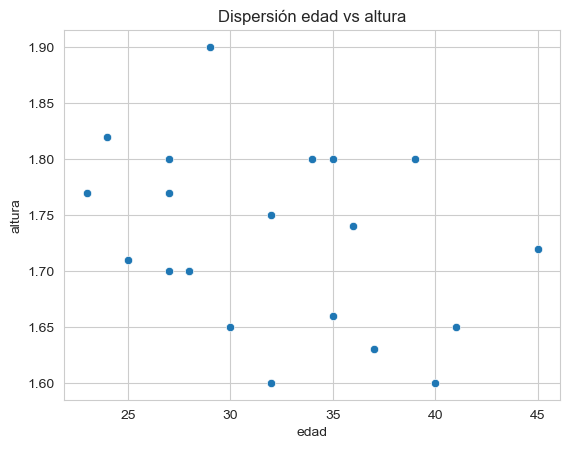

In [6]:
# Dibujamos un scatter plot para ver la nube de puntos edad vs altura
# Si hubiera relación lineal, los puntos se alinearían siguiendo una pendiente clara
sns.scatterplot(data=df, x="edad", y="altura")
plt.title("Dispersión edad vs altura")
plt.show()

**Conclusión del análisis descriptivo:**

- La correlación de Pearson es **r ≈ -0,33** (negativa débil) y el p-valor (≈ 0,145) es mayor que 0,05, por lo que **no hay evidencia estadística** de relación lineal entre edad y altura en esta muestra.
- El coeficiente de determinación **r² ≈ 0,11** indica que la edad solo explica el ~11% de la variabilidad de la altura. El 89% restante se debe a otros factores (genética, sexo, etc.).
- Biológicamente tiene sentido: entre los 23 y los 45 años la altura adulta ya está fijada y no depende de la edad.
- Con solo 21 observaciones, además, la muestra es demasiado pequeña para extraer conclusiones robustas.

**Por tanto, la regresión lineal NO es una buena técnica para este problema.** Aun así, entrenamos el modelo como pide el enunciado para comprobar empíricamente que funciona mal.

### Entrena un modelo de regresión lineal

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [8]:
# X son las features (variables predictoras): en este caso solo la edad.
# Usamos doble corchete [[ ]] para obtener un DataFrame 2D, que es lo que espera sklearn.
X = df[["edad"]]

# y es la variable objetivo (la altura). Con un solo corchete obtenemos una Serie 1D.
y = df["altura"]

# Dividimos los datos en train (80%) y test (20%).
# random_state=42 hace que la división sea reproducible (siempre salga igual).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} registros    Test: {X_test.shape[0]} registros")

Train: 16 registros    Test: 5 registros


In [9]:
# Creamos una instancia del modelo de regresión lineal (todavía sin entrenar)
modelo = LinearRegression()

# Entrenamos el modelo con los datos de train: busca la mejor recta y = a + b*edad
modelo.fit(X_train, y_train)

# Imprimimos el intercepto (a, el punto donde la recta cruza el eje Y)
# y la pendiente (b, cuánto cambia la altura por cada año más)
print(f"Intercepto (a): {modelo.intercept_:.4f}")
print(f"Pendiente (b): {modelo.coef_[0]:.6f}")
print(f"Ecuación: altura = {modelo.intercept_:.4f} + ({modelo.coef_[0]:.6f}) * edad")

Intercepto (a): 1.8581
Pendiente (b): -0.004357
Ecuación: altura = 1.8581 + (-0.004357) * edad


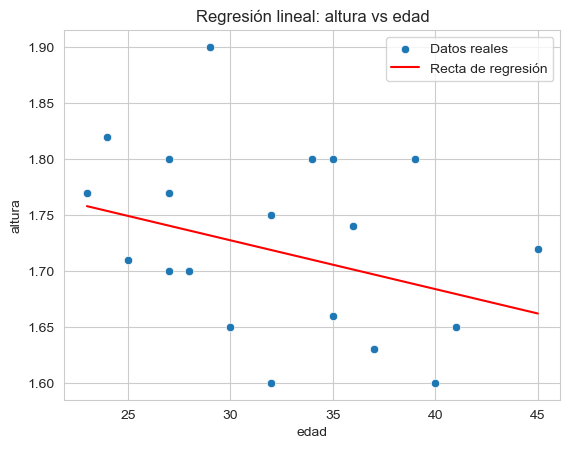

In [10]:
# Dibujamos la recta de regresión sobre la nube de puntos
# Primero pintamos todos los puntos
sns.scatterplot(data=df, x="edad", y="altura", label="Datos reales")

# Generamos predicciones para el rango completo de edades para dibujar la recta
# Usamos un DataFrame con la columna 'edad' para que coincida con las features del entrenamiento
edades_plot = pd.DataFrame({"edad": np.linspace(df["edad"].min(), df["edad"].max(), 100)})
alturas_plot = modelo.predict(edades_plot)

# Pintamos la recta en rojo encima del scatter
plt.plot(edades_plot, alturas_plot, color="red", label="Recta de regresión")
plt.title("Regresión lineal: altura vs edad")
plt.legend()
plt.show()

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [11]:
# Generamos las predicciones sobre el conjunto de test
y_pred = modelo.predict(X_test)

# Comparamos valores reales con predichos
comparacion = pd.DataFrame({"real": y_test.values, "predicho": y_pred})
# Añadimos la columna de error (residuo)
comparacion["error"] = comparacion["real"] - comparacion["predicho"]
comparacion

,real,predicho,error
0,1.82,1.753478,0.066522
1,1.80,1.709906,0.090094
2,1.75,1.718621,0.031379
3,1.71,1.749121,-0.039121
4,1.74,1.701192,0.038808


In [12]:
# --- Errores calculados MANUALMENTE con numpy ---

# Calculamos los errores (residuos) como la diferencia entre real y predicho
errores = y_test.values - y_pred

# MAE (Mean Absolute Error): media del valor absoluto de los errores
# np.abs() pone todos los errores en positivo antes de promediar
mae_manual = np.mean(np.abs(errores))

# MSE (Mean Squared Error): media de los errores al cuadrado
# Elevar al cuadrado castiga más los errores grandes
mse_manual = np.mean(errores ** 2)

# RMSE (Root Mean Squared Error): raíz cuadrada del MSE
# Así el error vuelve a estar en las mismas unidades que y (metros)
rmse_manual = np.sqrt(mse_manual)

# MAPE (Mean Absolute Percentage Error): media del error absoluto en porcentaje
# Dividimos el error entre el valor real para expresarlo como porcentaje
mape_manual = np.mean(np.abs(errores / y_test.values)) * 100

print("Errores MANUALES:")
print(f"  MAE  = {mae_manual:.6f}")
print(f"  MSE  = {mse_manual:.6f}")
print(f"  RMSE = {rmse_manual:.6f}")
print(f"  MAPE = {mape_manual:.4f} %")

Errores MANUALES:
  MAE  = 0.053185
  MSE  = 0.003313
  RMSE = 0.057556
  MAPE = 2.9943 %


In [13]:
# --- Errores usando las métricas de sklearn ---
# Importamos las funciones de métricas que nos pide el enunciado
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Cada función toma (y_real, y_predicho) y devuelve el error correspondiente
mae_sklearn  = mean_absolute_error(y_test, y_pred)
mse_sklearn  = mean_squared_error(y_test, y_pred)
rmse_sklearn = np.sqrt(mse_sklearn)
# mean_absolute_percentage_error devuelve proporción (0.03), multiplicamos por 100 para porcentaje
mape_sklearn = mean_absolute_percentage_error(y_test, y_pred) * 100

print("Errores con SKLEARN:")
print(f"  MAE  = {mae_sklearn:.6f}")
print(f"  MSE  = {mse_sklearn:.6f}")
print(f"  RMSE = {rmse_sklearn:.6f}")
print(f"  MAPE = {mape_sklearn:.4f} %")

# Comprobación: los valores manuales y los de sklearn deben coincidir
print("\n¿Coinciden los cálculos manuales con los de sklearn?")
print(f"  MAE:  {np.isclose(mae_manual, mae_sklearn)}")
print(f"  MSE:  {np.isclose(mse_manual, mse_sklearn)}")
print(f"  RMSE: {np.isclose(rmse_manual, rmse_sklearn)}")
print(f"  MAPE: {np.isclose(mape_manual, mape_sklearn)}")

Errores con SKLEARN:
  MAE  = 0.053185
  MSE  = 0.003313
  RMSE = 0.057556
  MAPE = 2.9943 %

¿Coinciden los cálculos manuales con los de sklearn?
  MAE:  True
  MSE:  True
  RMSE: True
  MAPE: True


In [14]:
# Calculamos también el R² en test para cerrar el diagnóstico
# R² mide qué fracción de la variabilidad de y explica el modelo.
# Máximo = 1 (modelo perfecto), 0 = igual que predecir la media, <0 = peor que la media.
r2_test = modelo.score(X_test, y_test)
print(f"R² en test: {r2_test:.4f}")

R² en test: -1.0398


### Conclusión final

- El MAE en test es de **~5,3 cm**, lo cual sobre alturas adultas (~170 cm) no es tan espectacular como parece. El MAPE es **~3%**.
- El dato más revelador es el **R² negativo en test**: el modelo predice *peor* que si simplemente contestásemos "la media" para todos. Esto confirma empíricamente lo que el análisis descriptivo ya mostraba: **no hay relación lineal entre edad y altura en adultos**.
- La regresión lineal no es la técnica adecuada para este problema porque falla la hipótesis fundamental: no existe relación lineal entre predictor y target.